In [1]:
# Imports torch packgaes
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils


device = (
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [2]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26421880/26421880 [00:01<00:00, 14874111.46it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 275391.65it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 5037885.40it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 14860479.69it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


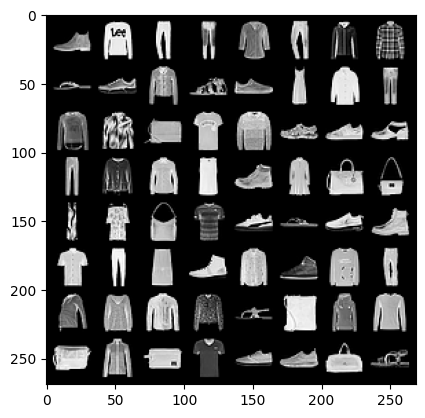

In [6]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    plt.imshow(np.transpose(vutils.make_grid(X.to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

In [7]:
## Define model
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         self.linear_relu_stack = nn.Sequential(
#             nn.Linear(28*28, 512),
#             nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.ReLU(),
#             nn.Linear(512, 10)
#         )

#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits



# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # if input is 1x1x28x28
#         self.conv_relu_stack = nn.Sequential(
#             nn.Conv2d(1,8,3), # 32x26x26
#             nn.ReLU(),
#             nn.Conv2d(8,16,3), # 16x24x24
#             nn.ReLU(),
#             nn.Conv2d(16,32,3), # 32x22x22
#             nn.ReLU(),
#         )


#         self.flatten = nn.Flatten() # feature size 32*22*22

#         self.linear_relu_stack = nn.Sequential(
#             nn.Linear(32*22*22, 512),
#             nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.ReLU(),
#             nn.Linear(512, 10), # 10 output feature
#         )

#     def forward(self, x):
#         x = self.conv_relu_stack(x)
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits


class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # if input is 1x1x28x28
        self.conv_relu_stack = nn.Sequential(
            nn.Conv2d(1,16,5), # 1x16x24x24
            nn.MaxPool2d(2), # 1x16x12x12
            nn.Conv2d(16,32,5,padding='valid'), # 1x32x8x8
            nn.MaxPool2d(2) # 1x32x4x4

        )


        self.flatten = nn.Flatten() # feature size 32*4*4

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(32*4*4, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10), # 10 output feature
        )

    def forward(self, x):
        x = self.conv_relu_stack(x)
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (conv_relu_stack): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=valid)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [8]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [9]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

epochs = 40

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.299751  [   64/60000]
loss: 2.296868  [ 6464/60000]
loss: 2.297422  [12864/60000]
loss: 2.302250  [19264/60000]
loss: 2.286640  [25664/60000]
loss: 2.294588  [32064/60000]
loss: 2.291329  [38464/60000]
loss: 2.287791  [44864/60000]
loss: 2.290349  [51264/60000]
loss: 2.288877  [57664/60000]
Test Error: 
 Accuracy: 10.7%, Avg loss: 2.283850 

Epoch 2
-------------------------------
loss: 2.284013  [   64/60000]
loss: 2.281259  [ 6464/60000]
loss: 2.275264  [12864/60000]
loss: 2.282052  [19264/60000]
loss: 2.266464  [25664/60000]
loss: 2.265949  [32064/60000]
loss: 2.268384  [38464/60000]
loss: 2.257420  [44864/60000]
loss: 2.264508  [51264/60000]
loss: 2.252064  [57664/60000]
Test Error: 
 Accuracy: 37.3%, Avg loss: 2.246353 

Epoch 3
-------------------------------
loss: 2.253825  [   64/60000]
loss: 2.248847  [ 6464/60000]
loss: 2.225550  [12864/60000]
loss: 2.234277  [19264/60000]
loss: 2.214133  [25664/60000]
loss: 2.185996  [32064/600

KeyboardInterrupt: 

In [ ]:
# Saving trained model
torch.save(model.state_dict(), "model_conv_2.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [11]:
# Loading pretrained model
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model_conv_2.pth"))

<All keys matched successfully>

In [12]:
loader = iter(test_dataloader)


predicted :       Ankle boot  actual :  Ankle boot
predicted :         Pullover  actual :  Pullover
predicted :          Trouser  actual :  Trouser
predicted :          Trouser  actual :  Trouser
predicted :            Shirt  actual :  Shirt
predicted :          Trouser  actual :  Trouser
predicted :             Coat  actual :  Coat
predicted :            Shirt  actual :  Shirt
predicted :           Sandal  actual :  Sandal
predicted :          Sneaker  actual :  Sneaker
predicted :             Coat  actual :  Coat
predicted :           Sandal  actual :  Sandal
predicted :           Sandal  actual :  Sneaker
predicted :            Dress  actual :  Dress
predicted :             Coat  actual :  Coat
predicted :          Trouser  actual :  Trouser
predicted :         Pullover  actual :  Pullover
predicted :            Shirt  actual :  Coat
predicted :              Bag  actual :  Bag
predicted :      T-shirt/top  actual :  T-shirt/top
predicted :         Pullover  actual :  Pullover
predic

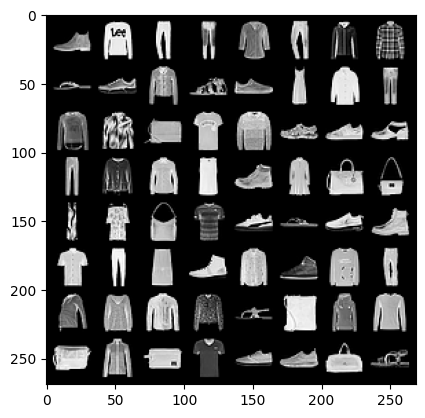

In [13]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


model.eval()
x,y = next(loader)

with torch.no_grad():
    plt.imshow(np.transpose(vutils.make_grid(x.to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))
    x = x.to(device)
    pred = model(x)
    predicted = [classes[int(i.argmax(0))] for i in pred]
    actual = [classes[i] for i in y]
    true = 0;
    for i in range(len(predicted)):
        if(predicted[i] ==  actual[i]):
            true += 1
        print("predicted : ","%15s"%predicted[i], " actual : ",actual[i])

    print("percentage of predicted as true : ",true/len(predicted))
